# Energy Consumption Forecasting Pipeline

This notebook builds an end-to-end pipeline for:

-  energy consumption forecasting
- anomaly detection
- cost optimization
- LLM summarization with Gemini

It is designed for records shaped like the sample JSON document provided by the user.

## Workflow

1. Load raw energy records
2. Convert timestamps and build time-based features
3. Create lag and rolling window features
4. Train a forecasting model
5. Score anomalies with forecast residuals and Isolation Forest
6. Estimate cost optimization opportunities
7. Generate a business summary using Gemini

In [ ]:
import json
import os
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.multioutput import MultiOutputRegressor  # predicting multiple numerical values simultaneously (multi-step time series forecasting)
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.impute import SimpleImputer # handle missing data in datasets by replacing missing values with a specified strategy
from sklearn.pipeline import Pipeline  # chain together multiple steps in a machine learning workflow
from sklearn.compose import ColumnTransformer

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 200)

## Data Loading

In [ ]:
from pymongo import MongoClient, DESCENDING
client = MongoClient("string") 
db = client["IOT"]
collection = db["EnergyConsumption_Dummy"]  

In [4]:
query = {"meter_id": "BLDG-A-MAIN-001"}
cursor = collection.find(query).sort("_id", DESCENDING)
data = list(cursor)
df = pd.DataFrame(data)

In [5]:
df.shape

(2000, 23)

## Feature Engineering

In [6]:
TARGET_COLS = ['hvac_kwh', 'lighting_kwh', 'machinery_kwh', 'it_kwh', 'total_kwh', 'net_grid_kwh', 'energy_cost_usd']
BASE_FEATURES = [
    'temperature_c', 'humidity_pct', 'occupancy', 'solar_gen_kwh', 'voltage_v',
    'power_factor', 'tariff_per_kwh', 'demand_response', 'hour_of_day',
    'day_of_week', 'is_weekend', 'is_business_hours'
]

# captures periodicity
def add_time_signals(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['hour_sin'] = np.sin(2 * np.pi * out['hour_of_day'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['hour_of_day'] / 24)
    out['dow_sin'] = np.sin(2 * np.pi * out['day_of_week'] / 7)
    out['dow_cos'] = np.cos(2 * np.pi * out['day_of_week'] / 7)
    return out

# yesterday/hour ago usage
def add_lag_features(df: pd.DataFrame, cols: List[str], lags: List[int] = [1, 2, 3, 6, 12, 24]) -> pd.DataFrame:
    out = df.copy()
    for col in cols:
        for lag in lags:
            out[f'{col}_lag_{lag}'] = out.groupby('meter_id')[col].shift(lag)
    return out

# smoothing trends
def add_rolling_features(df: pd.DataFrame, cols: List[str], windows: List[int] = [3, 6, 24]) -> pd.DataFrame:
    out = df.copy()
    for col in cols:
        for window in windows:
            rolled = out.groupby('meter_id')[col].rolling(window=window, min_periods=1)
            out[f'{col}_roll_mean_{window}'] = rolled.mean().reset_index(level=0, drop=True)
            out[f'{col}_roll_std_{window}'] = rolled.std().reset_index(level=0, drop=True)
    return out


feature_df = add_time_signals(df)
feature_df = add_lag_features(feature_df, ['total_kwh', 'net_grid_kwh', 'hvac_kwh', 'energy_cost_usd'])
feature_df = add_rolling_features(feature_df, ['total_kwh', 'net_grid_kwh', 'energy_cost_usd'])
feature_df = feature_df.dropna().reset_index(drop=True)
feature_df.head()

,_id,timestamp,meter_id,temperature_c,humidity_pct,occupancy,hvac_kwh,lighting_kwh,machinery_kwh,it_kwh,total_kwh,solar_gen_kwh,net_grid_kwh,voltage_v,power_factor,tariff_per_kwh,energy_cost_usd,cumulative_kwh,demand_response,hour_of_day,day_of_week,is_weekend,is_business_hours,hour_sin,hour_cos,dow_sin,dow_cos,total_kwh_lag_1,total_kwh_lag_2,total_kwh_lag_3,total_kwh_lag_6,total_kwh_lag_12,total_kwh_lag_24,net_grid_kwh_lag_1,net_grid_kwh_lag_2,net_grid_kwh_lag_3,net_grid_kwh_lag_6,net_grid_kwh_lag_12,net_grid_kwh_lag_24,hvac_kwh_lag_1,hvac_kwh_lag_2,hvac_kwh_lag_3,hvac_kwh_lag_6,hvac_kwh_lag_12,hvac_kwh_lag_24,energy_cost_usd_lag_1,energy_cost_usd_lag_2,energy_cost_usd_lag_3,energy_cost_usd_lag_6,energy_cost_usd_lag_12,energy_cost_usd_lag_24,total_kwh_roll_mean_3,total_kwh_roll_std_3,total_kwh_roll_mean_6,total_kwh_roll_std_6,total_kwh_roll_mean_24,total_kwh_roll_std_24,net_grid_kwh_roll_mean_3,net_grid_kwh_roll_std_3,net_grid_kwh_roll_mean_6,net_grid_kwh_roll_std_6,net_grid_kwh_roll_mean_24,net_grid_kwh_roll_std_24,energy_cost_usd_roll_mean_3,energy_cost_usd_roll_std_3,energy_cost_usd_roll_mean_6,energy_cost_usd_roll_std_6,energy_cost_usd_roll_mean_24,energy_cost_usd_roll_std_24
0,69d3a2913c5e0c50432b60f4,2026-03-24 01:30:00,BLDG-A-MAIN-001,21.03,75.8,0,17.955,1.658,5.052,12.679,37.344,2.329,35.015,226.63,0.965,0.14,4.9021,136206.50,0,7,1,0,0,0.965926,-2.588190e-01,0.781831,0.62349,88.490,94.223,91.572,87.844,41.374,36.032,76.525,75.109,70.300,62.578,41.374,31.648,30.646,32.273,28.237,27.308,20.859,16.987,10.7135,18.0262,16.8719,15.0187,5.7924,4.4307,73.352333,31.315601,85.456000,24.153621,65.675167,25.755207,62.216333,23.567683,69.339167,17.494303,58.547375,18.566148,11.213933,6.576346,14.782383,5.822760,10.506071,7.152783
1,69d3a2913c5e0c50432b60f3,2026-03-24 00:30:00,BLDG-A-MAIN-001,20.43,76.6,0,16.369,0.500,11.738,11.850,40.457,0.000,40.457,234.91,0.896,0.14,5.6640,136169.16,0,6,1,0,0,1.000000,6.123234e-17,0.781831,0.62349,37.344,88.490,94.223,97.171,90.013,33.854,35.015,76.525,75.109,74.157,90.013,33.854,17.955,30.646,32.273,28.563,23.907,17.698,4.9021,10.7135,18.0262,17.7976,21.6032,4.7396,55.430333,28.672790,76.003667,29.218406,65.950292,25.433766,50.665667,22.559536,63.722500,20.745793,58.822500,18.230201,7.093200,3.158331,12.760117,6.618741,10.544588,7.122808
2,69d3a2913c5e0c50432b60f2,2026-03-23 23:30:00,BLDG-A-MAIN-001,19.65,75.3,0,21.080,1.929,1.747,13.579,38.334,0.000,38.334,229.52,0.879,0.08,3.0667,136128.70,0,5,1,0,0,0.965926,2.588190e-01,0.781831,0.62349,40.457,37.344,88.490,103.936,77.897,39.002,40.457,35.015,76.525,84.929,74.516,39.002,16.369,17.955,30.646,30.577,26.299,23.903,5.6640,4.9021,10.7135,20.3830,17.8838,3.1202,38.711667,1.590492,65.070000,28.948556,65.922458,25.464886,37.935333,2.742816,55.956667,19.924612,58.794667,18.262260,4.544267,1.335112,9.874067,6.401827,10.542358,7.125240
3,69d3a2913c5e0c50432b60f1,2026-03-23 22:30:00,BLDG-A-MAIN-001,19.23,76.6,4,22.502,1.628,7.480,12.337,43.947,0.000,43.947,233.27,0.945,0.08,3.5158,136090.37,0,4,1,0,0,0.866025,5.000000e-01,0.781831,0.62349,38.334,40.457,37.344,91.572,96.726,45.314,38.334,40.457,35.015,70.300,84.443,45.314,21.080,16.369,17.955,28.237,30.351,26.185,3.0667,5.6640,4.9021,16.8719,20.2664,3.6252,40.912667,2.834108,57.132500,26.667943,65.865500,25.514466,40.912667,2.834108,51.564500,19.014231,58.737708,18.308207,4.082167,1.388190,7.648050,5.773109,10.537800,7.129891
4,69d3a2913c5e0c50432b60f0,2026-03-23 21:30:00,BLDG-A-MAIN-001,14.08,69.3,0,37.124,1.965,5.718,12.097,56.904,0.000,56.904,233.59,0.932,0.08,4.5523,136046.42,0,3,1,0,0,0.707107,7.071068e-01,0.781831,0.62349,43.947,38.334,40.457,94.223,96.748,35.668,43.947,38.334,40.457,75.109,81.079,35.668,22.502,21.080,16.369,32.273,28.878,21.373,3.5158,3.0667,5.6640,18.0262,19.4590,2.8534,46.395000,9.523957,50.912667,19.738921,66.750333,24.779333,46.395000,9.523957,48.530333,15.662916,59.622542,17.645963,3.711600,0.761909,5.402400,2.766367,10.608588,7.058356


## Train / Test Split

In [7]:
# Chronological split (important for time-series)
split_idx = int(len(feature_df) * 0.8)
train_df = feature_df.iloc[:split_idx].copy()
test_df = feature_df.iloc[split_idx:].copy()

excluded = {'timestamp', '_id', 'meter_id', 'cumulative_kwh'}
model_features = [c for c in feature_df.columns if c not in excluded.union(TARGET_COLS)]

X_train = train_df[model_features]
y_train = train_df[TARGET_COLS]
X_test = test_df[model_features]
y_test = test_df[TARGET_COLS]

len(model_features), X_train.shape, y_train.shape

(58, (1580, 58), (1580, 7))

## Multivariate Forecasting Model

The model predicts several dependent variables together:

- component-level energy use
- total energy
- net grid draw
- energy cost

In [ ]:
# explicitly define which columns go into the model
numeric_features = model_features

# preprocess data so that only numeric features are used
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]), numeric_features)
    ],
    remainder='drop' # Drops unused columns
)

forecast_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', MultiOutputRegressor(RandomForestRegressor(
            n_estimators=250,
            max_depth=12,
            random_state=42,
            n_jobs=-1
        )))
    ]
)

forecast_model.fit(X_train, y_train)
pred = pd.DataFrame(forecast_model.predict(X_test), columns=TARGET_COLS, index=X_test.index)
pred.head()

,hvac_kwh,lighting_kwh,machinery_kwh,it_kwh,total_kwh,net_grid_kwh,energy_cost_usd
1580,30.756752,1.411255,5.581873,12.148656,47.682868,26.794533,3.656577
1581,46.333542,1.591818,7.633938,12.169099,76.972242,30.696382,6.884146
1582,39.451679,1.621272,6.936558,11.962487,62.961983,26.785122,6.187985
1583,67.120877,1.440933,7.398927,12.209049,105.448828,46.039720,7.208278
1584,35.670514,1.521294,5.848686,12.161483,54.463955,46.445991,5.953053


In [11]:
def regression_metrics(actual: pd.DataFrame, predicted: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in actual.columns:
        mae = mean_absolute_error(actual[col], predicted[col])
        rmse = root_mean_squared_error(actual[col], predicted[col])
        mape = np.mean(np.abs((actual[col] - predicted[col]) / np.clip(actual[col], 1e-6, None))) * 100
        rows.append({'target': col, 'MAE': mae, 'RMSE': rmse, 'MAPE_pct': mape})
    return pd.DataFrame(rows).sort_values('RMSE')


metrics_df = regression_metrics(y_test, pred)
metrics_df

,target,MAE,RMSE,MAPE_pct
1,lighting_kwh,0.410285,0.520705,25.170923
3,it_kwh,0.779272,1.000070,6.083874
6,energy_cost_usd,0.904944,2.182513,201.688703
2,machinery_kwh,2.891000,3.541090,80.241194
5,net_grid_kwh,2.907911,3.663522,4.819271
0,hvac_kwh,2.771410,7.139467,5.723283
4,total_kwh,5.969356,14.484794,205.666871


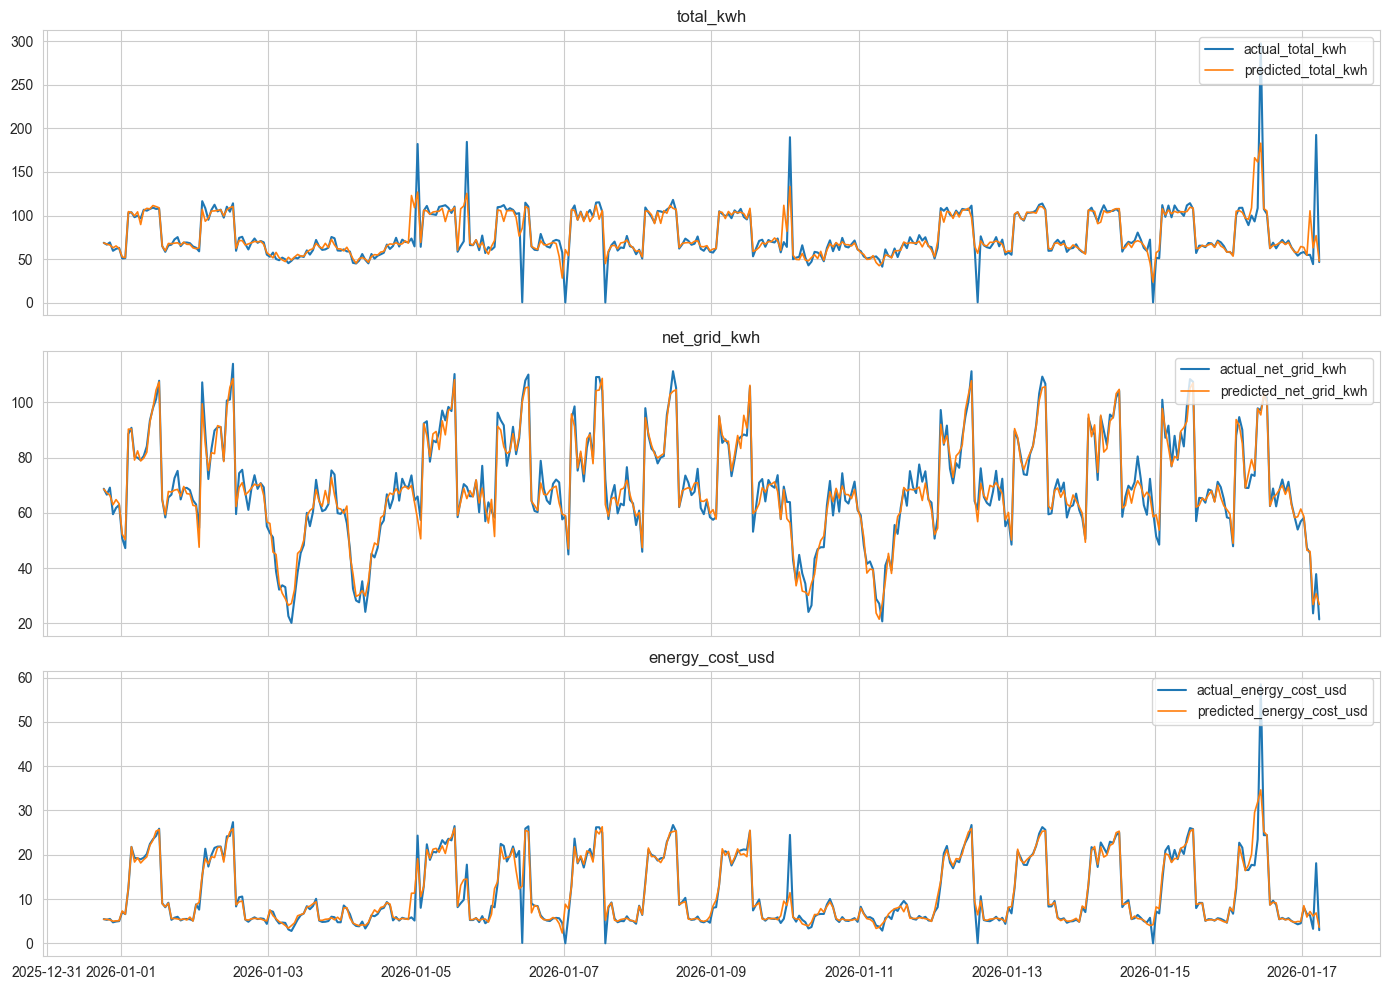

In [12]:
plot_cols = ['total_kwh', 'net_grid_kwh', 'energy_cost_usd']
fig, axes = plt.subplots(len(plot_cols), 1, figsize=(14, 10), sharex=True)

for ax, col in zip(axes, plot_cols):
    ax.plot(test_df['timestamp'], y_test[col], label=f'actual_{col}', linewidth=1.5)
    ax.plot(test_df['timestamp'], pred[col], label=f'predicted_{col}', linewidth=1.2)
    ax.set_title(col)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Anomaly Detection

Anomalies are identified using two signals:

- large forecast residuals
- unsupervised anomaly scoring with Isolation Forest

In [ ]:
results = test_df[['timestamp', 'meter_id'] + TARGET_COLS].copy()

for col in TARGET_COLS:
    results[f'pred_{col}'] = pred[col]
    # Residual = actual − predicted
    # Positive → underprediction
    # Negative → overprediction
    results[f'resid_{col}'] = results[col] - results[f'pred_{col}'] 
    resid_std = results[f'resid_{col}'].std() if results[f'resid_{col}'].std() > 0 else 1.0
    results[f'z_{col}'] = results[f'resid_{col}'] / resid_std  # Standardize across different scales, Makes features comparable

residual_cols = [f'resid_{c}' for c in TARGET_COLS]
# unsupervised anomaly detection algorithm based on the idea that anomalies are easier to isolate than normal points. Detects anomalies by isolating rare patterns. 3% expected anomalies
iso = IsolationForest(n_estimators=200, contamination=0.03, random_state=42)  
# Fit + Predict
# -1 → anomaly
# 1 → normal
results['iso_flag'] = iso.fit_predict(results[residual_cols])
# Higher score → normal
# Lower → more anomalous
results['iso_score'] = iso.decision_function(results[residual_cols])

# Detects extreme deviations
results['residual_rule_flag'] = (
    results[[f'z_{c}' for c in ['total_kwh', 'net_grid_kwh', 'energy_cost_usd']]].abs().max(axis=1) > 3
).astype(int)

# Combines ML + rule
results['anomaly_flag'] = ((results['iso_flag'] == -1) | (results['residual_rule_flag'] == 1)).astype(int)
results['anomaly_severity'] = (
    results[[f'z_{c}' for c in ['total_kwh', 'net_grid_kwh', 'energy_cost_usd']]].abs().max(axis=1)
).round(3)

anomalies = results[results['anomaly_flag'] == 1].sort_values('anomaly_severity', ascending=False)
anomalies[['timestamp', 'meter_id', 'total_kwh', 'pred_total_kwh', 'energy_cost_usd', 'pred_energy_cost_usd', 'anomaly_severity']].head(15)

,timestamp,meter_id,total_kwh,pred_total_kwh,energy_cost_usd,pred_energy_cost_usd,anomaly_severity
1599,2026-01-16 10:30:00,BLDG-A-MAIN-001,297.493,182.964225,58.4923,34.645303,10.913
1581,2026-01-17 04:30:00,BLDG-A-MAIN-001,192.441,76.972242,18.1029,6.884146,7.962
1752,2026-01-10 01:30:00,BLDG-A-MAIN-001,189.823,133.286148,24.4933,11.452020,5.968
1839,2026-01-06 10:30:00,BLDG-A-MAIN-001,0.476,85.454660,0.1142,12.948698,5.874
1601,2026-01-16 08:30:00,BLDG-A-MAIN-001,93.226,166.280764,17.6155,29.587153,5.479
1825,2026-01-07 00:30:00,BLDG-A-MAIN-001,0.258,60.854267,0.0361,8.850997,4.178
1857,2026-01-05 16:30:00,BLDG-A-MAIN-001,184.483,125.416893,17.7809,14.521096,4.073
1840,2026-01-06 09:30:00,BLDG-A-MAIN-001,102.736,76.465372,20.8713,12.314872,3.916
1691,2026-01-12 14:30:00,BLDG-A-MAIN-001,0.440,56.664332,0.0617,6.471254,3.877
1600,2026-01-16 09:30:00,BLDG-A-MAIN-001,108.579,161.419219,23.4921,31.904691,3.850


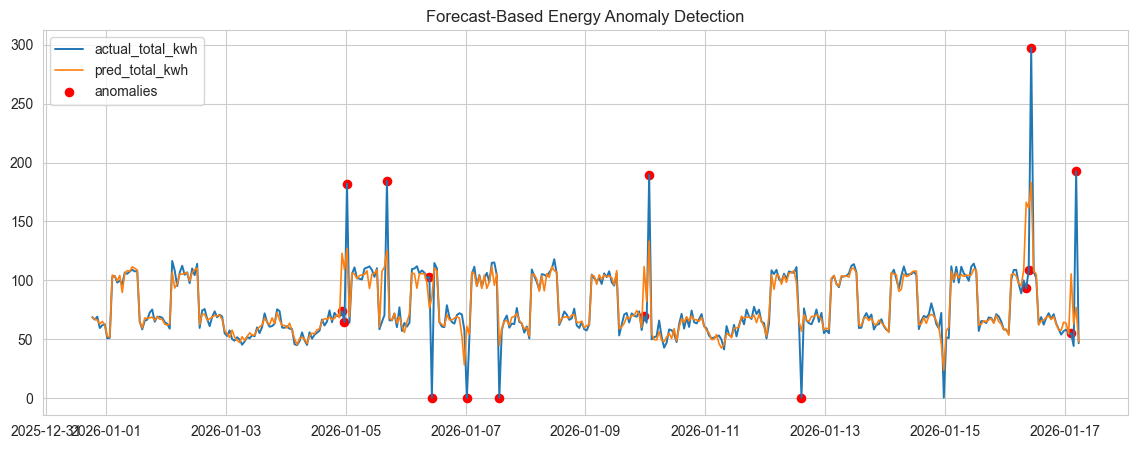

In [14]:
plt.figure(figsize=(14, 5))
plt.plot(results['timestamp'], results['total_kwh'], label='actual_total_kwh', linewidth=1.4)
plt.plot(results['timestamp'], results['pred_total_kwh'], label='pred_total_kwh', linewidth=1.2)
plt.scatter(
    anomalies['timestamp'],
    anomalies['total_kwh'],
    color='red',
    s=35,
    label='anomalies'
)
plt.title('Forecast-Based Energy Anomaly Detection')
plt.legend()
plt.show()

## Cost Optimization

This section creates simple operational recommendations:

- shift flexible load from high tariff hours to low tariff hours
- increase solar self-consumption where possible
- reduce abnormal HVAC overuse

This is a practical heuristic optimizer, not a full mathematical optimization engine.

Think of this like a factory trying to reduce its electricity bill smartly. Some machines and lights don’t need to run during expensive “peak hours,” so their usage can be shifted to cheaper times—this is your *flexible load*. At the same time, if the HVAC (cooling/heating) is using more energy than expected, it indicates inefficiency (like overcooling), and a portion of that can be reduced. The system compares high vs low electricity prices (tariff gap) and estimates how much money you’d save by shifting or reducing this energy. It also considers solar power - if you generate your own energy, you offset grid usage and save more. Overall, it’s like identifying *where energy is being wasted or poorly timed* and turning that into *practical cost savings*.


In [ ]:
def optimize_cost_window(df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict]:
    out = df.copy()
    
    # Assumes: 20% machinery + 10% lighting can be shifted (Identifies energy that can be moved to cheaper hours)
    out['flexible_kwh'] = out['machinery_kwh'] * 0.20 + out['lighting_kwh'] * 0.10
    # If actual > predicted → inefficiency
    out['avoidable_hvac_kwh'] = np.maximum(out['hvac_kwh'] - out['pred_hvac_kwh'], 0) * 0.25
    # Combines shiftable + reducible energy
    out['optimizable_kwh'] = out['flexible_kwh'] + out['avoidable_hvac_kwh']

    # Identify peak vs off-peak
    high_tariff = out['tariff_per_kwh'] >= out['tariff_per_kwh'].quantile(0.75)
    low_tariff = out['tariff_per_kwh'] <= out['tariff_per_kwh'].quantile(0.25)

    avg_high_tariff = out.loc[high_tariff, 'tariff_per_kwh'].mean()
    avg_low_tariff = out.loc[low_tariff, 'tariff_per_kwh'].mean()
    tariff_gap = max(avg_high_tariff - avg_low_tariff, 0)

    # Estimate benefit of load shifting
    out['estimated_shift_savings_usd'] = np.where(high_tariff, out['optimizable_kwh'] * tariff_gap, 0)
    # Captures renewable benefit: 5% efficiency factor
    out['estimated_solar_savings_usd'] = np.minimum(out['solar_gen_kwh'], out['net_grid_kwh']) * out['tariff_per_kwh'] * 0.05
    # Combined optimization gain
    out['estimated_total_savings_usd'] = out['estimated_shift_savings_usd'] + out['estimated_solar_savings_usd']

    summary = {
        'current_cost_usd': float(out['energy_cost_usd'].sum()),
        'estimated_savings_usd': float(out['estimated_total_savings_usd'].sum()),
        'optimized_cost_usd': float(out['energy_cost_usd'].sum() - out['estimated_total_savings_usd'].sum()),
        'avg_high_tariff': float(avg_high_tariff),
        'avg_low_tariff': float(avg_low_tariff),
        'tariff_gap': float(tariff_gap)
    }
    return out, summary


optimization_df, optimization_summary = optimize_cost_window(results.join(test_df[['tariff_per_kwh', 'solar_gen_kwh', 'machinery_kwh', 'lighting_kwh', 'hvac_kwh']], rsuffix="_test"))
optimization_summary

{'current_cost_usd': 4448.7883,
 'estimated_savings_usd': 203.52912086969909,
 'optimized_cost_usd': 4245.259179130301,
 'avg_high_tariff': 0.2400000000000001,
 'avg_low_tariff': 0.08,
 'tariff_gap': 0.1600000000000001}

In [17]:
top_savings = optimization_df.sort_values('estimated_total_savings_usd', ascending=False)[[
    'timestamp', 'energy_cost_usd', 'estimated_shift_savings_usd',
    'estimated_solar_savings_usd', 'estimated_total_savings_usd'
]].head(15)
top_savings

,timestamp,energy_cost_usd,estimated_shift_savings_usd,estimated_solar_savings_usd,estimated_total_savings_usd
1599,2026-01-16 10:30:00,58.4923,4.715516,0.122220,4.837736
1939,2026-01-02 06:30:00,21.5651,1.803728,0.270384,2.074112
1627,2026-01-15 06:30:00,21.1010,1.749685,0.283668,2.033353
1870,2026-01-05 03:30:00,22.3703,1.706364,0.213408,1.919772
1795,2026-01-08 06:30:00,18.6982,1.587120,0.328056,1.915176
1629,2026-01-15 04:30:00,21.9865,1.657136,0.238332,1.895468
1650,2026-01-14 07:30:00,21.5313,1.630463,0.264708,1.895171
1844,2026-01-06 05:30:00,18.4875,1.548687,0.345156,1.893843
1864,2026-01-05 09:30:00,22.4470,1.654768,0.219660,1.874428
1605,2026-01-16 04:30:00,21.6246,1.642710,0.225624,1.868334


## Business Summary Payload

In [18]:
def build_summary_payload(metrics_df: pd.DataFrame, anomalies: pd.DataFrame, optimization_summary: Dict) -> Dict:
    return {
        'forecast_metrics': metrics_df.round(4).to_dict(orient='records'),
        'anomaly_count': int(anomalies.shape[0]),
        'top_anomalies': anomalies[[
            'timestamp', 'total_kwh', 'pred_total_kwh', 'energy_cost_usd', 'pred_energy_cost_usd', 'anomaly_severity'
        ]].head(10).assign(timestamp=lambda x: x['timestamp'].astype(str)).to_dict(orient='records'),
        'optimization_summary': {k: round(v, 4) if isinstance(v, float) else v for k, v in optimization_summary.items()}
    }


summary_payload = build_summary_payload(metrics_df, anomalies, optimization_summary)
summary_payload

{'forecast_metrics': [{'target': 'lighting_kwh',
   'MAE': 0.4103,
   'RMSE': 0.5207,
   'MAPE_pct': 25.1709},
  {'target': 'it_kwh', 'MAE': 0.7793, 'RMSE': 1.0001, 'MAPE_pct': 6.0839},
  {'target': 'energy_cost_usd',
   'MAE': 0.9049,
   'RMSE': 2.1825,
   'MAPE_pct': 201.6887},
  {'target': 'machinery_kwh',
   'MAE': 2.891,
   'RMSE': 3.5411,
   'MAPE_pct': 80.2412},
  {'target': 'net_grid_kwh',
   'MAE': 2.9079,
   'RMSE': 3.6635,
   'MAPE_pct': 4.8193},
  {'target': 'hvac_kwh', 'MAE': 2.7714, 'RMSE': 7.1395, 'MAPE_pct': 5.7233},
  {'target': 'total_kwh',
   'MAE': 5.9694,
   'RMSE': 14.4848,
   'MAPE_pct': 205.6669}],
 'anomaly_count': 16,
 'top_anomalies': [{'timestamp': '2026-01-16 10:30:00',
   'total_kwh': 297.493,
   'pred_total_kwh': 182.96422495665476,
   'energy_cost_usd': 58.4923,
   'pred_energy_cost_usd': 34.64530347639947,
   'anomaly_severity': 10.913},
  {'timestamp': '2026-01-17 04:30:00',
   'total_kwh': 192.441,
   'pred_total_kwh': 76.97224208330488,
   'energy_co

## Gemini Summary

In [ ]:
def build_gemini_prompt(payload: Dict) -> str:
    return f'''
You are an energy analytics assistant.

Create a concise business summary from this pipeline output.
The response must include:
1. forecast quality summary
2. main anomaly patterns
3. likely operational causes
4. cost optimization opportunities
5. a prioritized action list for facilities and energy teams

Pipeline output:
{json.dumps(payload, indent=2)}
'''

def gemini_summary(payload: Dict, model_name: str = 'models/gemini-2.5-flash') -> str:
    api_key = "GEMINI_API_KEY"
    if not api_key:
        return 'GEMINI_API_KEY not set. Skipping LLM summary.'

    try:
        from google import genai
        client = genai.Client(api_key="GEMINI_API_KEY")
        response = client.models.generate_content(model=model_name, contents=build_gemini_prompt(payload))
        return response.text
    except Exception as exc:
        return f'Gemini summary failed: {exc}'


llm_summary = gemini_summary(summary_payload)
print(llm_summary)

**Energy Performance Business Summary**

**1. Forecast Quality Summary:**
Energy forecasting quality is highly variable. While `Net Grid`, `HVAC`, and `IT` consumption forecasts are generally reliable (MAPE < 7%), `total_kwh` and `energy_cost_usd` forecasts are currently unreliable (MAPE > 200%). This unreliability is significantly influenced by poor forecast accuracy for `lighting_kwh` (MAPE 25%) and `machinery_kwh` (MAPE 80%).

**2. Main Anomaly Patterns:**
The analysis identified 16 anomalies. Key patterns include both significant over-consumption events (e.g., actual usage up to 62% above predicted values, like 297 kWh vs 183 kWh predicted) and severe under-consumption instances where actual usage dropped to near zero (e.g., 0.4 kWh when 85 kWh was predicted). Over-consumption often occurred during daytime and early morning hours, while zero-reading under-consumption points to potential data issues.

**3. Likely Operational Causes:**
Significant over-consumption likely stems from m

## Final Pipeline Function

Use this function with your actual historical meter records.

In [ ]:
def run_energy_pipeline(input_df: pd.DataFrame) -> Dict:
    staged = add_time_signals(input_df)
    staged = add_lag_features(staged, ['total_kwh', 'net_grid_kwh', 'hvac_kwh', 'energy_cost_usd'])
    staged = add_rolling_features(staged, ['total_kwh', 'net_grid_kwh', 'energy_cost_usd'])
    staged = staged.dropna().reset_index(drop=True)

    split_idx = int(len(staged) * 0.8)
    train_df = staged.iloc[:split_idx].copy()
    test_df = staged.iloc[split_idx:].copy()

    excluded = {'timestamp', '_id', 'meter_id', 'cumulative_kwh'}
    feature_cols = [c for c in staged.columns if c not in excluded.union(TARGET_COLS)]

    X_train = train_df[feature_cols]
    y_train = train_df[TARGET_COLS]
    X_test = test_df[feature_cols]
    y_test = test_df[TARGET_COLS]

    model = Pipeline(
        steps=[
            ('preprocessor', ColumnTransformer(
                transformers=[('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]), feature_cols)],
                remainder='drop'
            )),
            ('model', MultiOutputRegressor(RandomForestRegressor(
                n_estimators=250,
                max_depth=12,
                random_state=42,
                n_jobs=-1
            )))
        ]
    )

    model.fit(X_train, y_train)
    pred = pd.DataFrame(model.predict(X_test), columns=TARGET_COLS, index=X_test.index)
    metrics = regression_metrics(y_test, pred)

    results = test_df[['timestamp', 'meter_id'] + TARGET_COLS].copy()
    for col in TARGET_COLS:
        results[f'pred_{col}'] = pred[col]
        results[f'resid_{col}'] = results[col] - results[f'pred_{col}']
        resid_std = results[f'resid_{col}'].std() if results[f'resid_{col}'].std() > 0 else 1.0
        results[f'z_{col}'] = results[f'resid_{col}'] / resid_std

    iso = IsolationForest(n_estimators=200, contamination=0.03, random_state=42)
    residual_cols = [f'resid_{c}' for c in TARGET_COLS]
    results['iso_flag'] = iso.fit_predict(results[residual_cols])
    results['iso_score'] = iso.decision_function(results[residual_cols])
    results['residual_rule_flag'] = (
        results[[f'z_{c}' for c in ['total_kwh', 'net_grid_kwh', 'energy_cost_usd']]].abs().max(axis=1) > 3
    ).astype(int)
    results['anomaly_flag'] = ((results['iso_flag'] == -1) | (results['residual_rule_flag'] == 1)).astype(int)
    results['anomaly_severity'] = results[[f'z_{c}' for c in ['total_kwh', 'net_grid_kwh', 'energy_cost_usd']]].abs().max(axis=1)

    anomalies = results[results['anomaly_flag'] == 1].sort_values('anomaly_severity', ascending=False)
    joined = results.join(test_df[['tariff_per_kwh', 'solar_gen_kwh', 'machinery_kwh', 'lighting_kwh', 'hvac_kwh']])
    optimization_df, optimization_summary = optimize_cost_window(joined)
    payload = build_summary_payload(metrics, anomalies, optimization_summary)
    llm_text = gemini_summary(payload)

    return {
        'model': model,
        'metrics': metrics,
        'predictions': pred,
        'results': results,
        'anomalies': anomalies,
        'optimization_df': optimization_df,
        'optimization_summary': optimization_summary,
        'summary_payload': payload,
        'llm_summary': llm_text
    }


pipeline_output = run_energy_pipeline(df)
pipeline_output['metrics']

In [ ]:
print('Anomalies detected:', len(pipeline_output['anomalies']))
print('Optimization summary:', pipeline_output['optimization_summary'])
print('\nGemini summary:\n')
print(pipeline_output['llm_summary'])